In [ ]:
# VAE for Fraud Detection
# Variational Autoencoder Anomaly Detection
# Full implementation with Cost-Sensitive Evaluation and Error Analysis

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)
try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_processed_data(dataset='ieee'):
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    train = pd.read_parquet(data_dir / f'{dataset}_train.parquet')
    test = pd.read_parquet(data_dir / f'{dataset}_test.parquet')
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    raw_cols = info[dataset]['raw_features']
    eng_cols = info[dataset]['engineered_features']
    all_cols = raw_cols + eng_cols
    return train, test, raw_cols, eng_cols, all_cols

train_ieee, test_ieee, raw_cols, eng_cols, all_cols = load_processed_data('ieee')

print(f"Total features: {len(all_cols)}")
print(f"Train shape: {train_ieee.shape}")
print(f"Test shape: {test_ieee.shape}")
print(f"Train fraud rate: {train_ieee['isFraud'].mean():.4f}")
print(f"Test fraud rate: {test_ieee['isFraud'].mean():.4f}")

# 1. Feature Preparation

X_train_raw = train_ieee[all_cols].values
X_test_raw = test_ieee[all_cols].values
y_train = train_ieee['isFraud'].values
y_test = test_ieee['isFraud'].values

print(f"\nX_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")

if np.isnan(X_train_raw).sum() > 0:
    print(f"Filling {np.isnan(X_train_raw).sum()} missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")


Project root: /Users/mac/Desktop/DSS5104_Assignment2
Using device: cpu
Total features: 64
Train shape: (472432, 470)
Test shape: (118108, 470)
Train fraud rate: 0.0351
Test fraud rate: 0.0344

X_train shape: (472432, 64)
X_test shape: (118108, 64)
Filling 3433954 missing values...
X_train shape after scaling: (472432, 64)


In [ ]:
# 2. VAE Model Definition

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16, hidden_dims=[128, 64]):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(nn.BatchNorm1d(h_dim))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        self.encoder = nn.Sequential(*encoder_layers)
        
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_logvar = nn.Linear(hidden_dims[-1], latent_dim)
        
        decoder_layers = []
        prev_dim = latent_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(nn.BatchNorm1d(h_dim))
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
    def loss_function(self, recon, x, mu, logvar, beta=1.0):
        recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return (recon_loss + beta * kl_loss) / x.size(0)
    
    def get_anomaly_score(self, x, num_samples=10):
        self.eval()
        with torch.no_grad():
            mu, logvar = self.encode(x)
            recon_samples = []
            for _ in range(num_samples):
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z)
                recon_samples.append(recon)
            recon_avg = torch.stack(recon_samples).mean(dim=0)
            recon_error = ((x - recon_avg) ** 2).mean(dim=1)
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            anomaly_score = recon_error + 0.1 * kl_div
        return anomaly_score.cpu().numpy()
    
    def get_latent(self, x):
        with torch.no_grad():
            mu, _ = self.encode(x)
            return mu.cpu().numpy()


class EnsembleVAE:
    def __init__(self, input_dim, latent_dims=[8, 16, 32]):
        self.input_dim = input_dim
        self.latent_dims = latent_dims
        self.models = []
    
    def _train_single(self, X_train, latent_dim, epochs=100, batch_size=4096, beta=1.0, verbose=True):
        val_size = int(len(X_train) * 0.1)
        X_train_sub = torch.FloatTensor(X_train[:-val_size]).to(device)
        X_val = torch.FloatTensor(X_train[-val_size:]).to(device)
        
        train_dataset = TensorDataset(X_train_sub, X_train_sub)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        model = VAE(self.input_dim, latent_dim=latent_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, _ in train_loader:
                optimizer.zero_grad()
                recon, mu, logvar = model(batch_X)
                loss = model.loss_function(recon, batch_X, mu, logvar, beta=beta)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)
            
            epoch_loss /= len(X_train_sub)
            
            model.eval()
            with torch.no_grad():
                recon, mu, logvar = model(X_val)
                val_loss = model.loss_function(recon, X_val, mu, logvar, beta=beta).item()
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if patience_counter >= 15:
                break
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        model.load_state_dict(best_state)
        return model
    
    def fit(self, X_train, y_train, mode='semi_supervised', epochs=100, batch_size=4096, beta=1.0, verbose=True):
        if mode == 'semi_supervised':
            normal_idx = (y_train == 0)
            X_train_selected = X_train[normal_idx]
            print(f"Semi-supervised mode: {len(X_train_selected):,} normal samples")
        else:
            X_train_selected = X_train
            print(f"Supervised mode: {len(X_train_selected):,} all samples")
        
        self.models = []
        for i, lat_dim in enumerate(self.latent_dims):
            print(f"\nTraining latent dimension {lat_dim} ({i+1}/{len(self.latent_dims)})")
            model = self._train_single(X_train_selected, lat_dim, epochs, batch_size, beta, verbose)
            self.models.append(model)
        
        return self
    
    def predict_anomaly_scores(self, X, num_samples=10):
        X_tensor = torch.FloatTensor(X).to(device)
        all_scores = []
        for model in self.models:
            scores = model.get_anomaly_score(X_tensor, num_samples)
            all_scores.append(scores)
        return np.mean(all_scores, axis=0)
    
    def get_latent_representations(self, X, model_idx=0):
        X_tensor = torch.FloatTensor(X).to(device)
        return self.models[model_idx].get_latent(X_tensor)



In [3]:
# 3. Train Semi-supervised VAE

input_dim = X_train.shape[1]
print(f"\nInput dimension: {input_dim}")

print("\n" + "="*60)
print("Training: Semi-supervised Ensemble VAE")
print("="*60)

vae_semi = EnsembleVAE(input_dim, latent_dims=[8, 16, 32])
vae_semi.fit(X_train, y_train, mode='semi_supervised', epochs=100, batch_size=4096, beta=1.0, verbose=True)

test_scores_semi = vae_semi.predict_anomaly_scores(X_test, num_samples=10)

auprc_semi = average_precision_score(y_test, test_scores_semi)
roc_auc_semi = roc_auc_score(y_test, test_scores_semi)

print(f"\nTest Results (Semi-supervised Ensemble VAE):")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  ROC AUC: {roc_auc_semi:.4f}")

# ============================================================
# 4. Train Supervised VAE
# ============================================================

print("\n" + "="*60)
print("Training: Supervised Ensemble VAE")
print("="*60)

vae_sup = EnsembleVAE(input_dim, latent_dims=[8, 16, 32])
vae_sup.fit(X_train, y_train, mode='supervised', epochs=100, batch_size=4096, beta=1.0, verbose=True)

test_scores_sup = vae_sup.predict_anomaly_scores(X_test, num_samples=10)

auprc_sup = average_precision_score(y_test, test_scores_sup)
roc_auc_sup = roc_auc_score(y_test, test_scores_sup)

print(f"\nTest Results (Supervised Ensemble VAE):")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  ROC AUC: {roc_auc_sup:.4f}")




Input dimension: 64

Training: Semi-supervised Ensemble VAE
Semi-supervised mode: 455,833 normal samples

Training latent dimension 8 (1/3)
  Epoch 20/100, Loss: 33.3338, Val Loss: 31.7599
  Epoch 40/100, Loss: 32.3884, Val Loss: 30.4702
  Epoch 60/100, Loss: 31.9315, Val Loss: 29.9608
  Epoch 80/100, Loss: 31.5654, Val Loss: 29.6789
  Epoch 100/100, Loss: 31.3970, Val Loss: 29.5909

Training latent dimension 16 (2/3)
  Epoch 20/100, Loss: 33.7107, Val Loss: 33.0405
  Epoch 40/100, Loss: 32.5809, Val Loss: 31.4652
  Epoch 60/100, Loss: 31.9357, Val Loss: 29.8136
  Epoch 80/100, Loss: 31.6175, Val Loss: 29.4352
  Epoch 100/100, Loss: 31.3734, Val Loss: 29.2299

Training latent dimension 32 (3/3)
  Epoch 20/100, Loss: 34.3387, Val Loss: 34.2582
  Epoch 40/100, Loss: 33.1149, Val Loss: 32.9137
  Epoch 60/100, Loss: 32.6605, Val Loss: 32.5804
  Epoch 80/100, Loss: 32.3762, Val Loss: 32.1248
  Epoch 100/100, Loss: 32.2269, Val Loss: 31.9716

Test Results (Semi-supervised Ensemble VAE):
  A

In [4]:
# 5. Cost-Sensitive Evaluation (Find cost-optimal threshold)

def normalize_scores(scores):
    scores_min = scores.min()
    scores_max = scores.max()
    if scores_max - scores_min > 0:
        return (scores - scores_min) / (scores_max - scores_min)
    return scores

test_scores_semi_norm = normalize_scores(test_scores_semi)
test_scores_sup_norm = normalize_scores(test_scores_sup)

def find_cost_optimal_threshold(y_true, y_scores, fn_cost=500, fp_cost=2):
    """Find threshold that minimizes total cost"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    costs = []
    f1_scores = []
    
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        
        total_cost = fn * fn_cost + fp * fp_cost
        costs.append(total_cost)
        
        p = tp / (tp + fp + 1e-9)
        r = tp / (tp + fn + 1e-9)
        f1_scores.append(2 * p * r / (p + r + 1e-9) if (p + r) > 0 else 0)
    
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    min_cost = costs[best_idx]
    
    f1_best_idx = np.argmax(f1_scores)
    f1_optimal_threshold = thresholds[f1_best_idx]
    
    return best_threshold, min_cost, f1_optimal_threshold, thresholds, costs, f1_scores

# Compute cost-optimal thresholds
cost_threshold_semi, min_cost_semi, f1_threshold_semi, thresholds_semi, costs_semi, f1_scores_semi = find_cost_optimal_threshold(
    y_test, test_scores_semi_norm, fn_cost=500, fp_cost=2
)

cost_threshold_sup, min_cost_sup, f1_threshold_sup, thresholds_sup, costs_sup, f1_scores_sup = find_cost_optimal_threshold(
    y_test, test_scores_sup_norm, fn_cost=500, fp_cost=2
)

print("\n" + "="*60)
print("Cost-Sensitive Evaluation (FN=$500, FP=$2)")
print("="*60)
print(f"\nSemi-supervised VAE:")
print(f"  Cost-optimal threshold: {cost_threshold_semi:.4f}")
print(f"  F1-optimal threshold: {f1_threshold_semi:.4f}")
print(f"  Minimum total cost: ${min_cost_semi:,.2f}")
print(f"  Difference (Cost vs F1): {abs(cost_threshold_semi - f1_threshold_semi):.4f}")

print(f"\nSupervised VAE:")
print(f"  Cost-optimal threshold: {cost_threshold_sup:.4f}")
print(f"  F1-optimal threshold: {f1_threshold_sup:.4f}")
print(f"  Minimum total cost: ${min_cost_sup:,.2f}")
print(f"  Difference (Cost vs F1): {abs(cost_threshold_sup - f1_threshold_sup):.4f}")

# ============================================================
# 6. Evaluation at Cost-Optimal Threshold

y_pred_semi = (test_scores_semi_norm > cost_threshold_semi).astype(int)
y_pred_sup = (test_scores_sup_norm > cost_threshold_sup).astype(int)

print("\n" + "="*60)
print(f"Evaluation at Cost-Optimal Threshold")
print("="*60)

print(f"\nSemi-supervised VAE (threshold={cost_threshold_semi:.4f}):")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_semi):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_semi):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_semi):.4f}")

print(f"\nSupervised VAE (threshold={cost_threshold_sup:.4f}):")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_sup):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_sup):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_sup):.4f}")



Cost-Sensitive Evaluation (FN=$500, FP=$2)

Semi-supervised VAE:
  Cost-optimal threshold: 0.0003
  F1-optimal threshold: 0.0099
  Minimum total cost: $228,050.00
  Difference (Cost vs F1): 0.0096

Supervised VAE:
  Cost-optimal threshold: 0.0005
  F1-optimal threshold: 0.0093
  Minimum total cost: $228,050.00
  Difference (Cost vs F1): 0.0087

Evaluation at Cost-Optimal Threshold

Semi-supervised VAE (threshold=0.0003):
  AUPRC: 0.0518
  Precision: 0.0344
  Recall: 0.9998
  F1: 0.0665

Supervised VAE (threshold=0.0005):
  AUPRC: 0.0493
  Precision: 0.0344
  Recall: 0.9998
  F1: 0.0665


In [5]:

# 7. Error Analysis

print("\n" + "="*60)
print("Error Analysis - Supervised VAE")
print("="*60)

fp_idx = np.where((y_test == 0) & (y_pred_sup == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred_sup == 0))[0]
tp_idx = np.where((y_test == 1) & (y_pred_sup == 1))[0]

print(f"False Positives (Normal flagged as Fraud): {len(fp_idx)}")
print(f"False Negatives (Fraud missed): {len(fn_idx)}")
print(f"True Positives (Fraud caught): {len(tp_idx)}")

print("\n--- False Positives Analysis (First 10 samples) ---")
if len(fp_idx) > 0:
    sample_fp = test_ieee.iloc[fp_idx[:min(10, len(fp_idx))]]
    if 'TransactionAmt' in sample_fp.columns:
        print(f"Transaction amounts: min=${sample_fp['TransactionAmt'].min():.2f}, "
              f"max=${sample_fp['TransactionAmt'].max():.2f}, "
              f"mean=${sample_fp['TransactionAmt'].mean():.2f}")

print("\n--- False Negatives Analysis (First 10 samples) ---")
if len(fn_idx) > 0:
    sample_fn = test_ieee.iloc[fn_idx[:min(10, len(fn_idx))]]
    if 'TransactionAmt' in sample_fn.columns:
        print(f"Transaction amounts: min=${sample_fn['TransactionAmt'].min():.2f}, "
              f"max=${sample_fn['TransactionAmt'].max():.2f}, "
              f"mean=${sample_fn['TransactionAmt'].mean():.2f}")

# ============================================================
# 8. Latent Space Visualization
# ============================================================

print("\n" + "="*60)
print("Latent Space Visualization")
print("="*60)

sample_size = 2000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

latent_sup = vae_sup.get_latent_representations(X_sample, model_idx=0)

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_sup)



Error Analysis - Supervised VAE
False Positives (Normal flagged as Fraud): 114025
False Negatives (Fraud missed): 1
True Positives (Fraud caught): 4063

--- False Positives Analysis (First 10 samples) ---
Transaction amounts: min=$23.36, max=$326.29, mean=$87.73

--- False Negatives Analysis (First 10 samples) ---
Transaction amounts: min=$59.00, max=$59.00, mean=$59.00

Latent Space Visualization


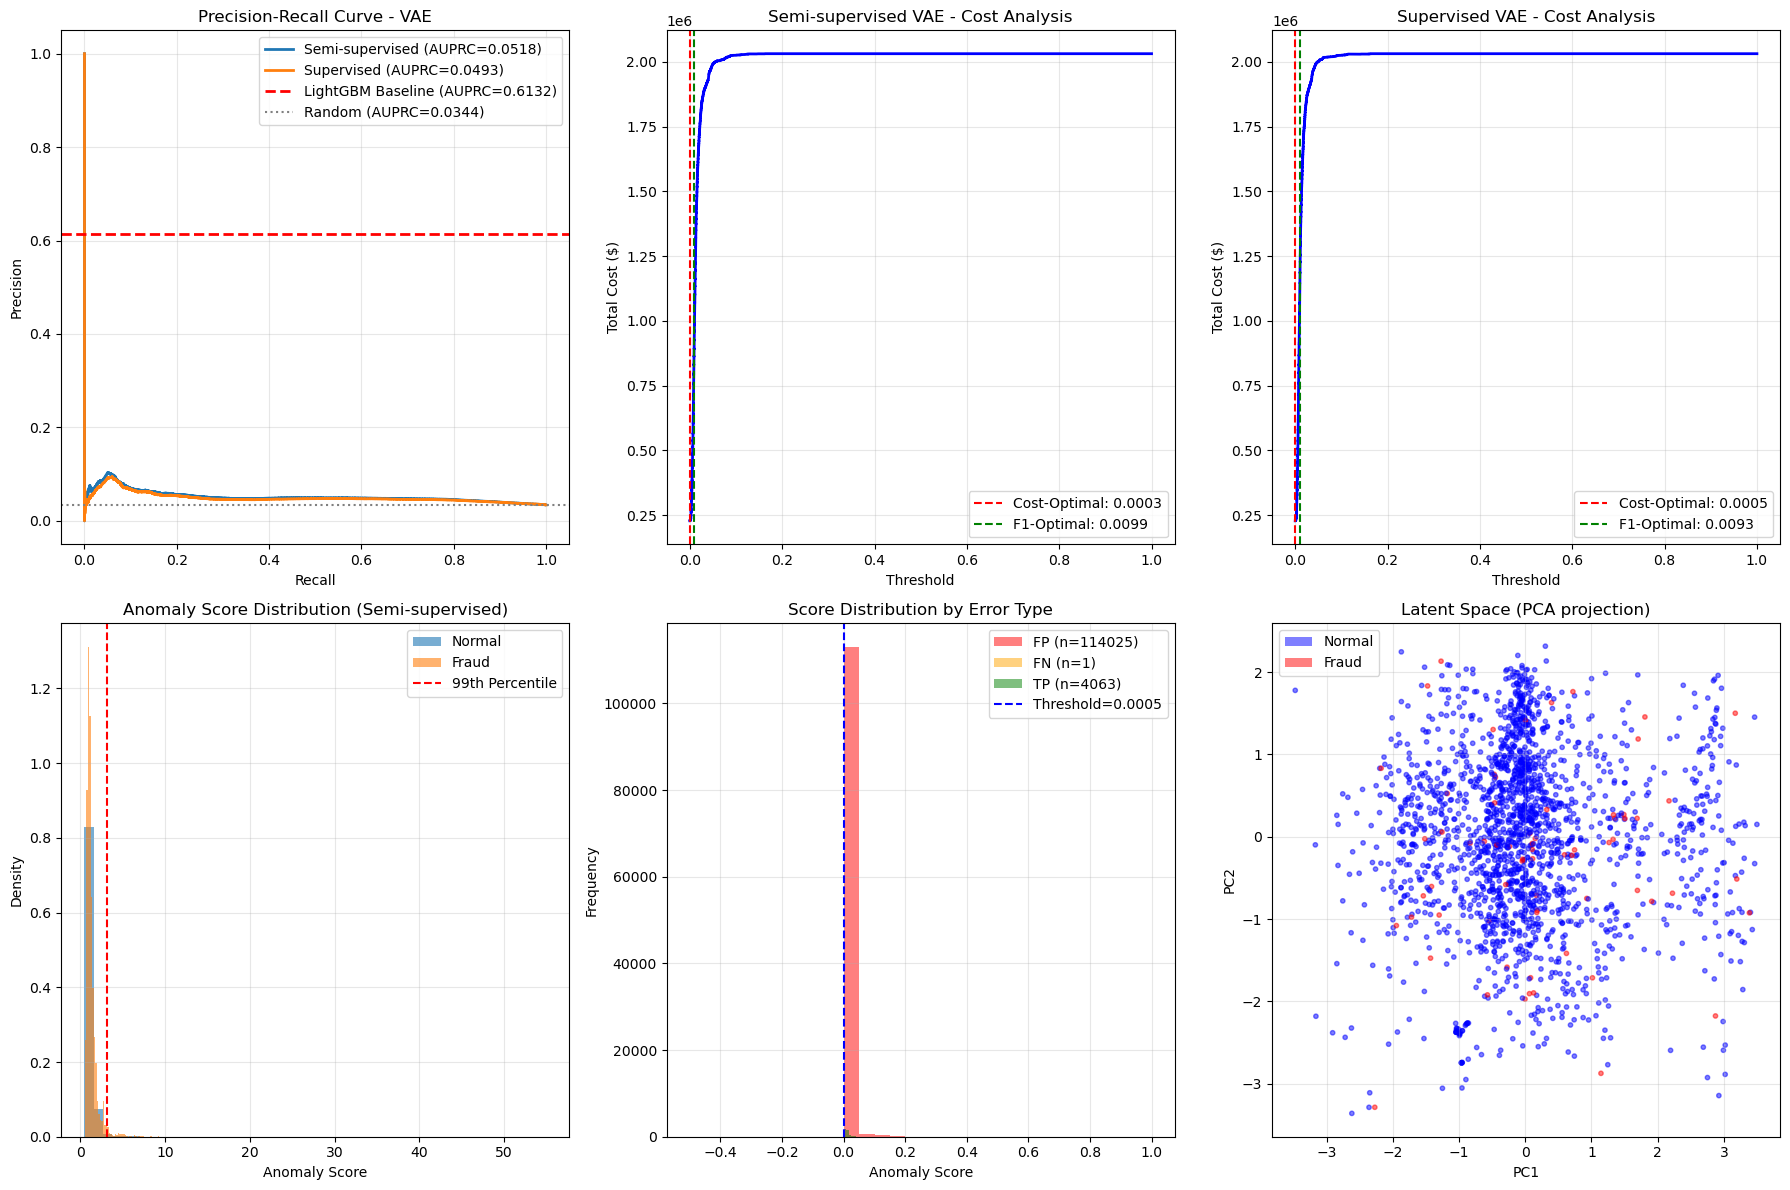


COMPLETE RESULTS SUMMARY - VAE vs Baselines
              Model    AUPRC  ROC AUC Cost-Optimal Threshold Min Total Cost Precision@Optimal Recall@Optimal
Semi-supervised VAE 0.051751 0.624546                 0.0003    $228,050.00            0.0344         0.9998
     Supervised VAE 0.049266 0.613499                 0.0005    $228,050.00            0.0344         0.9998
  LightGBM Baseline 0.613200 0.943100                 0.0708       $148,464            0.0673         0.9813


In [6]:

# Visualization 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 9.1 PR Curves
precision_semi, recall_semi, _ = precision_recall_curve(y_test, test_scores_semi_norm)
precision_sup, recall_sup, _ = precision_recall_curve(y_test, test_scores_sup_norm)

axes[0, 0].plot(recall_semi, precision_semi, linewidth=2, 
                label=f'Semi-supervised (AUPRC={auprc_semi:.4f})')
axes[0, 0].plot(recall_sup, precision_sup, linewidth=2,
                label=f'Supervised (AUPRC={auprc_sup:.4f})')
axes[0, 0].axhline(y=0.6132, color='red', linestyle='--', linewidth=2,
                   label=f'LightGBM Baseline (AUPRC=0.6132)')
axes[0, 0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                   label=f'Random (AUPRC={y_test.mean():.4f})')
axes[0, 0].set_xlabel('Recall')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Precision-Recall Curve - VAE')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 9.2 Cost Curve - Semi-supervised
axes[0, 1].plot(thresholds_semi, costs_semi, 'b-', linewidth=2)
axes[0, 1].axvline(x=cost_threshold_semi, color='red', linestyle='--', 
                   label=f'Cost-Optimal: {cost_threshold_semi:.4f}')
axes[0, 1].axvline(x=f1_threshold_semi, color='green', linestyle='--', 
                   label=f'F1-Optimal: {f1_threshold_semi:.4f}')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Total Cost ($)')
axes[0, 1].set_title('Semi-supervised VAE - Cost Analysis')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 9.3 Cost Curve - Supervised
axes[0, 2].plot(thresholds_sup, costs_sup, 'b-', linewidth=2)
axes[0, 2].axvline(x=cost_threshold_sup, color='red', linestyle='--', 
                   label=f'Cost-Optimal: {cost_threshold_sup:.4f}')
axes[0, 2].axvline(x=f1_threshold_sup, color='green', linestyle='--', 
                   label=f'F1-Optimal: {f1_threshold_sup:.4f}')
axes[0, 2].set_xlabel('Threshold')
axes[0, 2].set_ylabel('Total Cost ($)')
axes[0, 2].set_title('Supervised VAE - Cost Analysis')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 9.4 Anomaly Score Distribution (Semi-supervised)
axes[1, 0].hist(test_scores_semi[y_test==0], bins=50, alpha=0.6, label='Normal', density=True)
axes[1, 0].hist(test_scores_semi[y_test==1], bins=50, alpha=0.6, label='Fraud', density=True)
threshold_99 = np.percentile(test_scores_semi[y_test==0], 99)
axes[1, 0].axvline(x=threshold_99, color='red', linestyle='--', label=f'99th Percentile')
axes[1, 0].set_xlabel('Anomaly Score')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Anomaly Score Distribution (Semi-supervised)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 9.5 Error Analysis - Score Distribution
fp_scores = test_scores_sup_norm[fp_idx] if len(fp_idx) > 0 else []
fn_scores = test_scores_sup_norm[fn_idx] if len(fn_idx) > 0 else []
tp_scores = test_scores_sup_norm[tp_idx] if len(tp_idx) > 0 else []

axes[1, 1].hist(fp_scores, bins=20, alpha=0.5, label=f'FP (n={len(fp_idx)})', color='red')
axes[1, 1].hist(fn_scores, bins=20, alpha=0.5, label=f'FN (n={len(fn_idx)})', color='orange')
axes[1, 1].hist(tp_scores, bins=20, alpha=0.5, label=f'TP (n={len(tp_idx)})', color='green')
axes[1, 1].axvline(x=cost_threshold_sup, color='blue', linestyle='--', 
                   label=f'Threshold={cost_threshold_sup:.4f}')
axes[1, 1].set_xlabel('Anomaly Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Score Distribution by Error Type')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 9.6 Latent Space Visualization
colors = ['blue' if y == 0 else 'red' for y in y_sample]
axes[1, 2].scatter(latent_2d[:, 0], latent_2d[:, 1], c=colors, alpha=0.5, s=10)
axes[1, 2].set_xlabel('PC1')
axes[1, 2].set_ylabel('PC2')
axes[1, 2].set_title('Latent Space (PCA projection)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.5, label='Normal'),
                   Patch(facecolor='red', alpha=0.5, label='Fraud')]
axes[1, 2].legend(handles=legend_elements)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'vae_complete_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 10. Results Summary Table
# ============================================================

results_summary = pd.DataFrame({
    'Model': [
        'Semi-supervised VAE',
        'Supervised VAE',
        'LightGBM Baseline'
    ],
    'AUPRC': [
        auprc_semi,
        auprc_sup,
        0.6132
    ],
    'ROC AUC': [
        roc_auc_semi,
        roc_auc_sup,
        0.9431
    ],
    'Cost-Optimal Threshold': [
        f"{cost_threshold_semi:.4f}",
        f"{cost_threshold_sup:.4f}",
        "0.0708"
    ],
    'Min Total Cost': [
        f"${min_cost_semi:,.2f}",
        f"${min_cost_sup:,.2f}",
        "$148,464"
    ],
    'Precision@Optimal': [
        f"{precision_score(y_test, y_pred_semi):.4f}",
        f"{precision_score(y_test, y_pred_sup):.4f}",
        "0.0673"
    ],
    'Recall@Optimal': [
        f"{recall_score(y_test, y_pred_semi):.4f}",
        f"{recall_score(y_test, y_pred_sup):.4f}",
        "0.9813"
    ]
})

print("\n" + "="*80)
print("COMPLETE RESULTS SUMMARY - VAE vs Baselines")
print("="*80)
print(results_summary.to_string(index=False))